In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install xgboost

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score
from sklearn.metrics import fbeta_score

In [8]:
# 데이터 로드
df = pd.read_csv('../../data/insurance_policyholder_churn_synthetic.csv')
churn_df = df.copy()
df.head()

,customer_id,as_of_date,region_name,age,age_band,marital_status,customer_tenure_months,multi_policy_flag,num_policies,policy_type,...,avg_settlement_time_days,days_since_last_claim,num_contacts_12m,complaint_flag,complaint_resolution_days,quote_requested_flag,coverage_downgrade_flag,churn_flag,churn_type,churn_probability_true
0,1,2025-12-31,Manawatu-Whanganui,24,18-24,Married,128,1,4,Auto,...,7,1616,0,0,0,0,0,0,No churn,0.048626
1,2,2025-12-31,Auckland,70,65-74,Married,76,1,3,Auto,...,15,1760,1,0,0,0,0,0,No churn,0.067888
2,3,2025-12-31,Bay of Plenty,62,55-64,Married,129,0,1,Auto,...,24,1581,1,0,0,0,0,0,No churn,0.223765
3,4,2025-12-31,Bay of Plenty,47,45-54,Single,104,0,1,Auto,...,17,1688,1,0,0,0,0,0,No churn,0.602455
4,5,2025-12-31,Bay of Plenty,47,45-54,Married,22,1,3,Life,...,24,1592,1,0,0,0,0,0,No churn,0.050723


정답 컬럼 및 중복 컬럼 제거한 베이스 모델(ver2) 학습

In [21]:
# 1. 제거할 컬럼 리스트 (확실히 정의)
drop_cols = [
    'customer_id', 'as_of_date', 'age_band',   # 식별자 중복
    'churn_flag', 'churn_type', 'churn_probability_true',
    'num_approved_claims_12m', 'num_pending_claims_12m',
    'current_premium', 'premium_last_year'
]

# 2. X와 y를 만들 때 정제된 df를 사용
# df.drop을 실행한 결과를 X_data로 받음
X_data = df.drop(columns=drop_cols)

# 3. 범주형 변수 처리 (get_dummies)
X = pd.get_dummies(X_data, drop_first=True)
y = df['churn_flag']

# 정데데이터 로드 확인
print(f"X의 컬럼 개수: {len(X.columns)}")

# 4. 데이터 분할 (반드시 새로운 X, y로 분할)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. 모델 학습 (rf_2)
rf_2 = RandomForestClassifier(n_estimators=100, class_weight={0:1, 1:3}, random_state=42)
rf_2.fit(X_train, y_train)

X의 컬럼 개수: 38


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
# 우리가 버린 컬럼들이 리스트에 없는지 확인 (True가 나오면 잘 버린 것)
dt_cols = ['customer_id', 'churn_probability_true', 'churn_type', 'as_of_date']
is_clean = all(col not in X.columns for col in dt_cols)

print(f"삭제 완료 여부: {is_clean}")
print("-" * 30)
print(X.columns.tolist())

삭제 완료 여부: True
------------------------------
['age', 'customer_tenure_months', 'multi_policy_flag', 'num_policies', 'renewal_month', 'premium_change_pct', 'num_price_increases_last_3y', 'coverage_amount', 'premium_to_coverage_ratio', 'autopay_enabled', 'late_payment_count_12m', 'missed_payment_flag', 'payment_method_change_flag', 'num_claims_12m', 'num_rejected_claims_12m', 'avg_claim_amount', 'total_claim_amount_12m', 'total_payout_amount_12m', 'payout_ratio_12m', 'avg_settlement_time_days', 'days_since_last_claim', 'num_contacts_12m', 'complaint_flag', 'complaint_resolution_days', 'quote_requested_flag', 'coverage_downgrade_flag', 'region_name_Bay of Plenty', 'region_name_Canterbury', 'region_name_Manawatu-Whanganui', 'region_name_Otago', 'region_name_Waikato', 'region_name_Wellington', 'marital_status_Single', 'policy_type_Health', 'policy_type_Home', 'policy_type_Life', 'policy_type_Travel', 'payment_frequency_Monthly']


=== [1단계] 성능 지표 ===
정확도(Accuracy): 0.7645
AUC 점수: 0.7814
F2-Score (Recall 가중): 0.4036

[상세 분류 리포트]
              precision    recall  f1-score   support

           0       0.77      0.94      0.85      6983
           1       0.72      0.36      0.48      3017

    accuracy                           0.76     10000
   macro avg       0.74      0.65      0.67     10000
weighted avg       0.76      0.76      0.74     10000



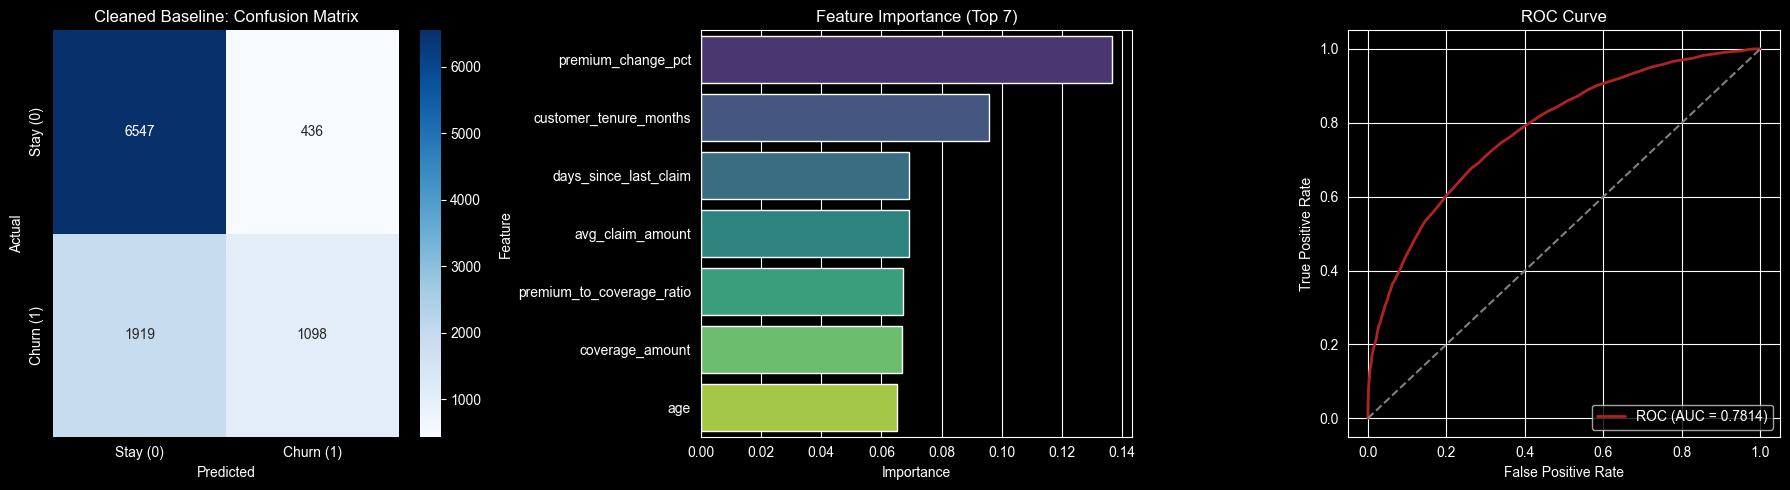

In [27]:
# 1. 모델 예측 (이미 학습된 rf_2 사용)
y_pred_v2 = rf_2.predict(X_test)
y_probs_v2 = rf_2.predict_proba(X_test)[:, 1]

# 2. 지표 계산
auc_v2 = roc_auc_score(y_test, y_probs_v2)
f2_v2 = fbeta_score(y_test, y_pred_v2, beta=2.0)
acc_v2 = accuracy_score(y_test, y_pred_v2)

# 지표 출력
print(f"=== [1단계] 성능 지표 ===")
print(f"정확도(Accuracy): {acc_v2:.4f}")
print(f"AUC 점수: {auc_v2:.4f}")
print(f"F2-Score (Recall 가중): {f2_v2:.4f}")
print("\n[상세 분류 리포트]")
print(classification_report(y_test, y_pred_v2))

# ---------------------------------------------------------
# 3. 시각화 (혼동행렬, 변수 중요도, ROC 커브)
# ---------------------------------------------------------
plt.figure(figsize=(18, 5))

# (1) 혼동행렬 (Confusion Matrix)
plt.subplot(1, 3, 1)
cm_v2 = confusion_matrix(y_test, y_pred_v2)
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay (0)', 'Churn (1)'],
            yticklabels=['Stay (0)', 'Churn (1)'])
plt.title('Cleaned Baseline: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# (2) 변수 중요도 (Top 7)
plt.subplot(1, 3, 2)
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_2.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

sns.barplot(data=importances.head(7), x='Importance', y='Feature', hue='Feature', palette='viridis')
plt.title('Feature Importance (Top 7)')

# (3) ROC 커브
plt.subplot(1, 3, 3)
fpr, tpr, _ = roc_curve(y_test, y_probs_v2)
plt.plot(fpr, tpr, color='firebrick', lw=2, label=f'ROC (AUC = {auc_v2:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [31]:
# 1. 모델의 예측 확률값 가져오기
# y_probs = rf_2.predict_proba(X_test)[:, 1]
#
# # 2. 임계치를0.3으로 낮추기(이탈확률이 30%만 넘어도 이탈자로 분류)
# custom_threshold = 0.3
# y_pred_new = (y_probs >= custom_threshold).astype(int)
#
# # 3. 지표 확인
# new_f2 = fbeta_score(y_test, y_pred_new, beta=2.0)
#
# print(f"--- 임계치 {custom_threshold} 적용 결과 ---")
# print(f"F2-Score: {new_f2:.4f}")
# print("\n[임계치 적용한 상세 분류 리포트]")
# print(classification_report(y_test, y_pred_new))

--- 임계치 0.3 적용 결과 ---
F2-Score: 0.6564

[임계치 적용한 상세 분류 리포트]
              precision    recall  f1-score   support

           0       0.85      0.70      0.77      6983
           1       0.51      0.71      0.59      3017

    accuracy                           0.70     10000
   macro avg       0.68      0.71      0.68     10000
weighted avg       0.74      0.70      0.71     10000



In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

# 1. F2-Score를 기준으로 모델을 평가하도록 설정 (beta=2.0)
f2_scorer = make_scorer(fbeta_score, beta=2.0)

# 2. 탐색할 하이퍼파라미터 범위 설정
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': [{0: 1, 1: 3}, {0: 1, 1: 5}]
}

# 3. GridSearchCV 설정 (5-Fold 교차 검증)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring=f2_scorer, # F2-Score를 높이는 방향으로 최적화!
    cv=5,
    n_jobs=-1, # 내 컴퓨터 자원 풀가동
    verbose=1
)

# 4. 튜닝 시작
grid_search.fit(X_train, y_train)

# 5. 최적의 파라미터 확인
print(f"최적의 파라미터: {grid_search.best_params_}")
print(f"최적의 F2-Score: {grid_search.best_score_:.4f}")

# 6. 최적의 모델로 최종 예측
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
최적의 파라미터: {'class_weight': {0: 1, 1: 5}, 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
최적의 F2-Score: 0.7171


=== [2단계] 최적화 모델 성능 지표 ===
최종 정확도(Accuracy): 0.5453
최종 AUC 점수: 0.7776
최종 F2-Score: 0.7177

[최종 상세 분류 리포트]
              precision    recall  f1-score   support

           0       0.91      0.39      0.54      6983
           1       0.39      0.91      0.55      3017

    accuracy                           0.55     10000
   macro avg       0.65      0.65      0.55     10000
weighted avg       0.75      0.55      0.54     10000



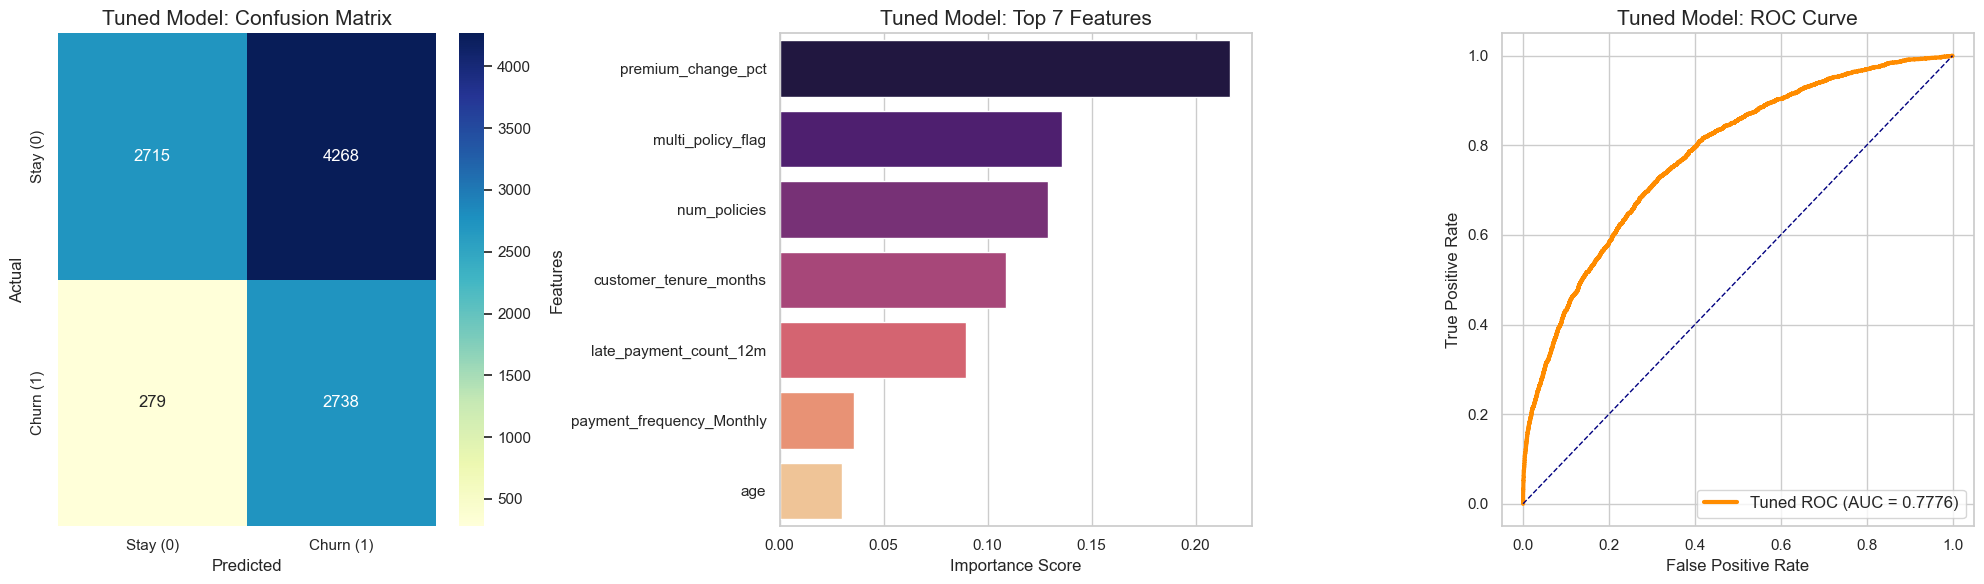

In [37]:
# 1. 최적 모델로 예측 및 지표 계산
y_pred_final = best_rf.predict(X_test)
y_probs_final = best_rf.predict_proba(X_test)[:, 1]

auc_final = roc_auc_score(y_test, y_probs_final)
f2_final = fbeta_score(y_test, y_pred_final, beta=2.0)
acc_final = accuracy_score(y_test, y_pred_final)

# [최종 지표 출력]
print(f"=== [2단계] 최적화 모델 성능 지표 ===")
print(f"최종 정확도(Accuracy): {acc_final:.4f}")
print(f"최종 AUC 점수: {auc_final:.4f}")
print(f"최종 F2-Score: {f2_final:.4f}")

# 2. 요약 리포트 출력
print("\n[최종 상세 분류 리포트]")
print(classification_report(y_test, y_pred_final))

# ---------------------------------------------------------
# 3. 시각화 (동일 형식: 혼동행렬, 변수 중요도, ROC 커브)
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 6))

# (1) 혼동행렬 (Confusion Matrix)
plt.subplot(1, 3, 1)
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Stay (0)', 'Churn (1)'],
            yticklabels=['Stay (0)', 'Churn (1)'])
plt.title('Tuned Model: Confusion Matrix', fontsize=15)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)

# (2) 변수 중요도 (Top 7)
plt.subplot(1, 3, 2)
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True).head(7)

sns.barplot(data=importances, x='Importance', y='Feature',
            hue='Feature', palette='magma', legend=False)
plt.title('Tuned Model: Top 7 Features', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# (3) ROC 커브
plt.subplot(1, 3, 3)
fpr, tpr, _ = roc_curve(y_test, y_probs_final)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'Tuned ROC (AUC = {auc_final:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.title('Tuned Model: ROC Curve', fontsize=15)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

## 파생변수 만들어서 학습

In [46]:
# 1. 변수 생성
claim_col = 'num_claims_12m' if 'num_claims_12m' in X.columns else 'num_claims_past_year'
reject_col = 'num_rejected_claims_12m'

# 1) 분노 지수 (Anger Index)
# 보험료 인상폭이 있고(>0), 청구 거절 경험이 있는 경우를 조합
X['anger_index'] = X['premium_change_pct'] * X[reject_col]

# 2) 청구 승인 효율 (Claim Efficiency)
# 전체 청구 시도 중 승인된 비율 (분모가 0인 경우를 대비해 아주 작은 값 0.1을 더함)
# 이 수치가 낮을수록 '가성비가 떨어진다'고 느끼는 고객
X['claim_rate'] = (X[claim_col] - X[reject_col]) / (X[claim_col] + 0.1)

# 3) 장기 고객 불만 지수 (Loyalty Pain)
# 가입 기간이 길수록(tenure) 불만이 생겼을 때의 이탈 파급력 큼
# complaint_flag가 1인 경우에만 가입 기간이 곱해지게함
X['loyalty_pain_score'] = X['customer_tenure_months'] * X['complaint_flag']

# 4) 최근 활동성 급락 (Activity Drop)
# 최근 6개월 청구가 12개월 평균보다 급격히 적은 경우를 추가로 확인해봄
if 'num_claims_6m' in X.columns:
    X['recent_activity_ratio'] = X['num_claims_6m'] / (X[claim_col] / 2 + 0.1)

print(f"현재 컬럼 수: {len(X.columns)}개")

# 2. 데이터 재분할 (새로운 변수 반영)
# ---------------------------------------------------------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. 최적 파라미터 모델 학습 (2단계 튜닝 결과 반영)
# ---------------------------------------------------------
final_rf = RandomForestClassifier(
    class_weight={0: 1, 1: 5},
    max_depth=12,
    min_samples_split=5,
    n_estimators=200,
    random_state=42
)
final_rf.fit(X_train, y_train)

현재 컬럼 수: 41개


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

=== [3단계] 성능 성적표 ===
최종 정확도(Accuracy): 0.5694
최종 AUC 점수: 0.7735
최종 F2-Score: 0.7152

[상세 분류 리포트]
              precision    recall  f1-score   support

           0       0.90      0.43      0.58      6983
           1       0.40      0.89      0.55      3017

    accuracy                           0.57     10000
   macro avg       0.65      0.66      0.57     10000
weighted avg       0.75      0.57      0.57     10000



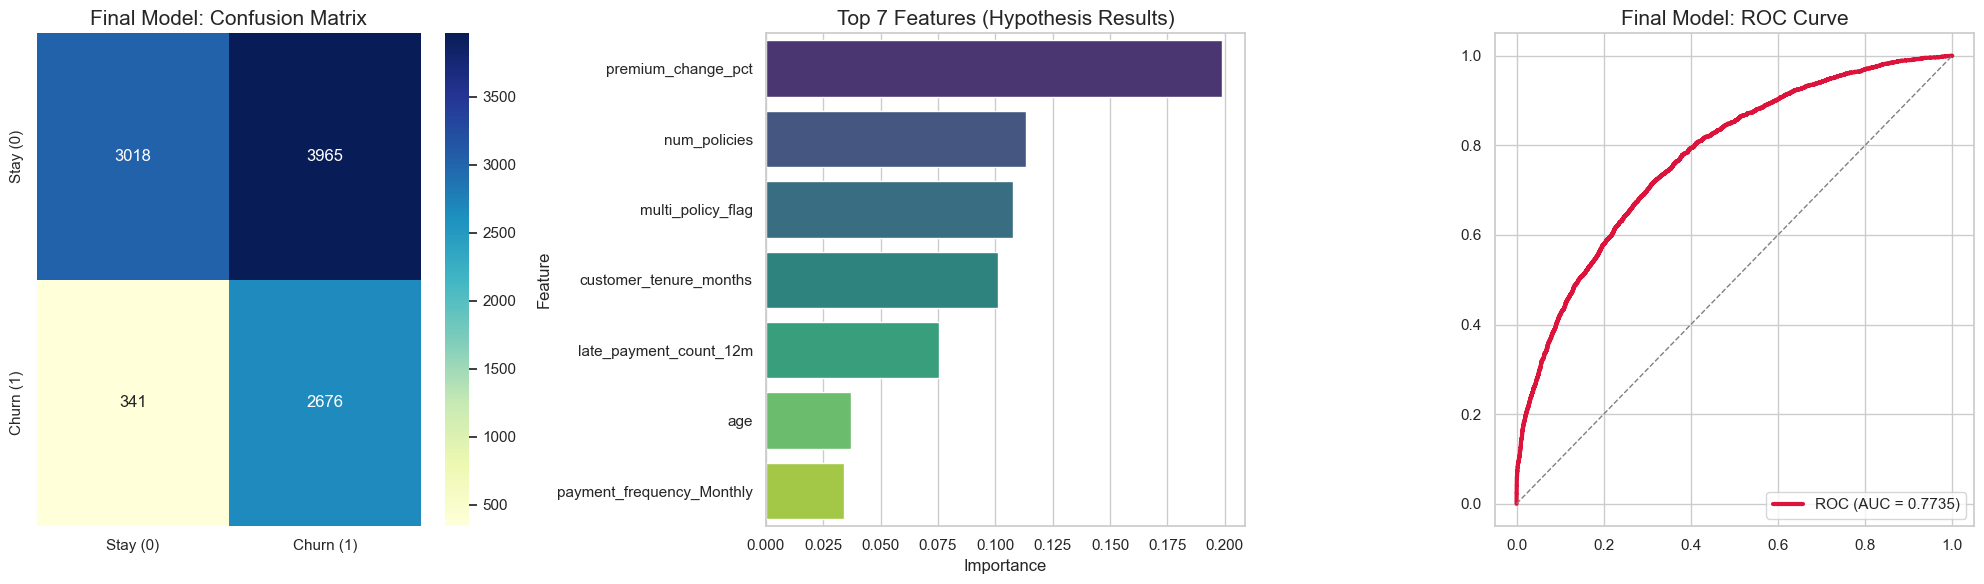

In [47]:
# 4. 예측 및 지표 계산
# ---------------------------------------------------------
y_pred_final = final_rf.predict(X_test)
y_probs_final = final_rf.predict_proba(X_test)[:, 1]

auc_val = roc_auc_score(y_test, y_probs_final)
f2_val = fbeta_score(y_test, y_pred_final, beta=2.0)
acc_val = accuracy_score(y_test, y_pred_final)

print(f"=== [3단계] 성능 성적표 ===")
print(f"최종 정확도(Accuracy): {acc_val:.4f}")
print(f"최종 AUC 점수: {auc_val:.4f}")
print(f"최종 F2-Score: {f2_val:.4f}")

print("\n[상세 분류 리포트]")
print(classification_report(y_test, y_pred_final))

# 5. 시각화 (혼동행렬, 변수 중요도, ROC 커브)
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 6))

# (1) 혼동행렬 (Confusion Matrix)
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Stay (0)', 'Churn (1)'],
            yticklabels=['Stay (0)', 'Churn (1)'])
plt.title('Final Model: Confusion Matrix', fontsize=15)

# (2) 변수 중요도 (Top 10) - 가설 변수 진입 확인용
plt.subplot(1, 3, 2)
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_rf.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True).head(7)

sns.barplot(data=importances, x='Importance', y='Feature',
            hue='Feature', palette='viridis', legend=False)
plt.title('Top 7 Features (Hypothesis Results)', fontsize=15)

# (3) ROC 커브
plt.subplot(1, 3, 3)
fpr, tpr, _ = roc_curve(y_test, y_probs_final)
plt.plot(fpr, tpr, color='crimson', lw=3, label=f'ROC (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.title('Final Model: ROC Curve', fontsize=15)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


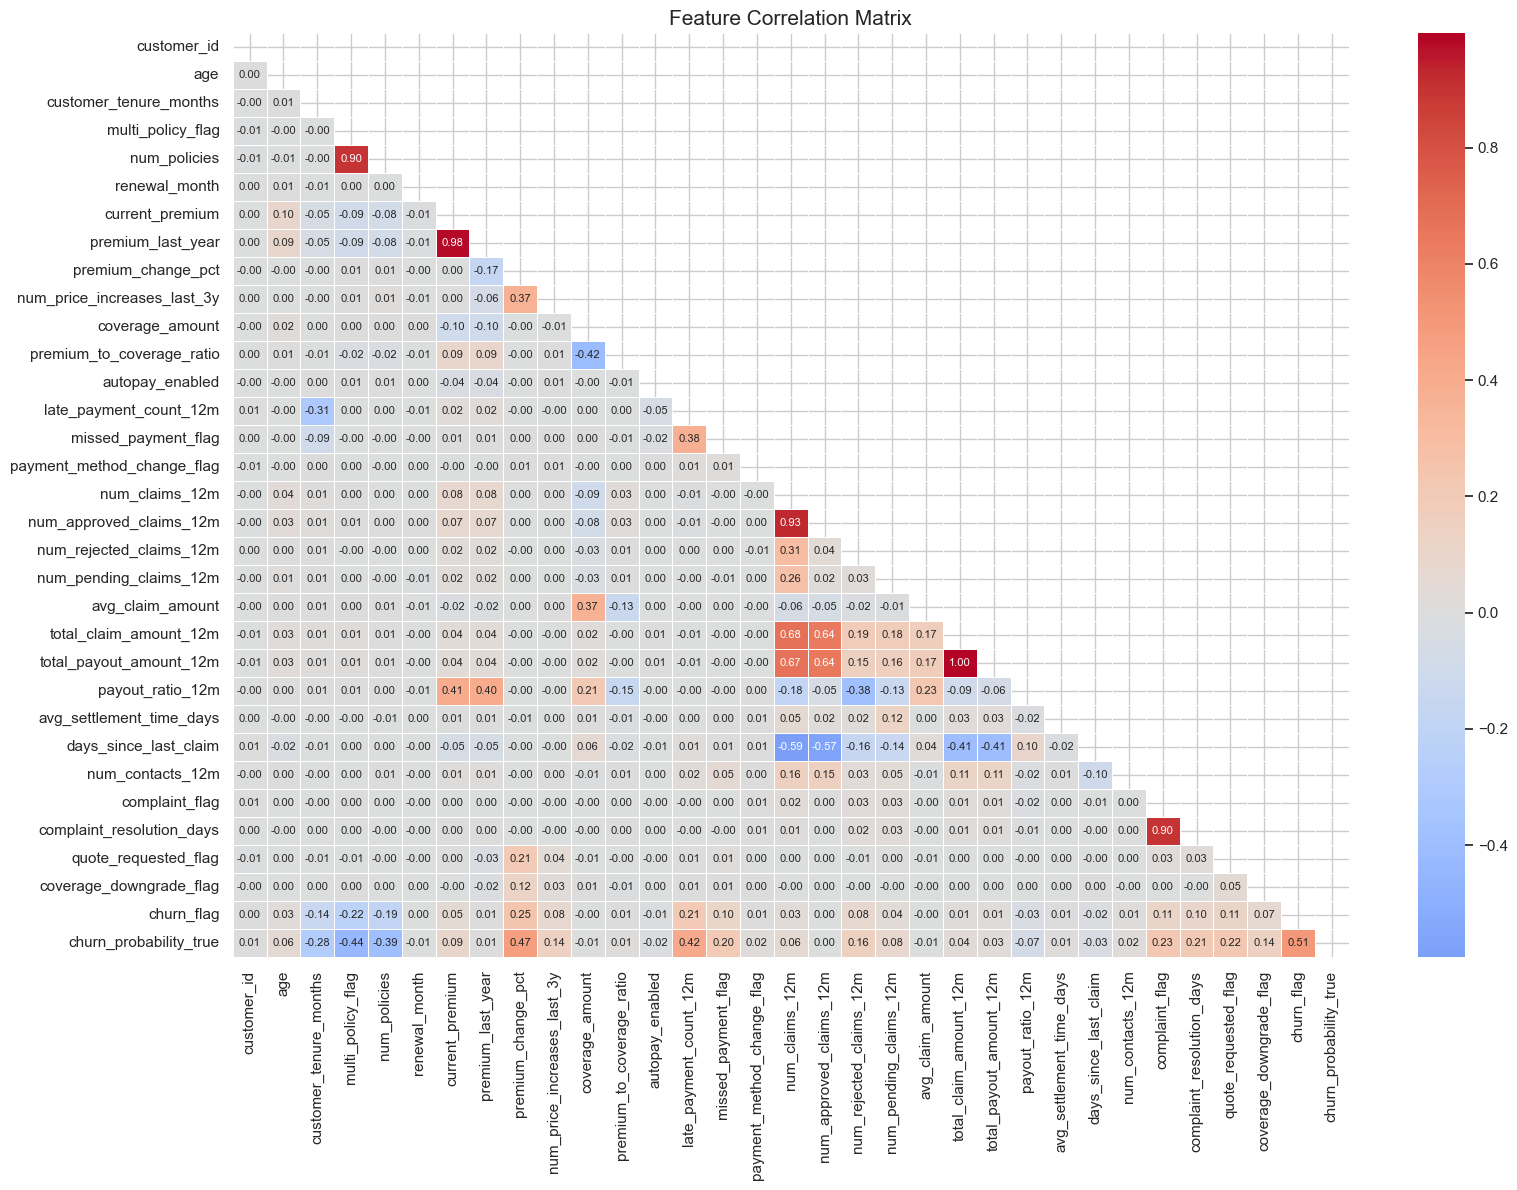

In [49]:
# 1. 상관계수 행렬 계산 (숫자형 컬럼만 선택 후 .corr() 호출 필수!)
# select_dtypes(include=[np.number])를 통해 문자열 컬럼을 제외
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# 2. 시각화 설정
plt.figure(figsize=(18, 12))

# 3. 상단 삼각형 마스크 생성
# corr_matrix가 정사각 행렬이므로 마스크가 정확히 적용됨.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. 히트맵 그리기
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,          # 숫자 표시
            fmt=".2f",           # 소수점 둘째자리까지
            cmap='coolwarm',     # 색상 팔레트
            center=0,
            linewidths=.5,
            annot_kws={"size": 8}) # 숫자가 너무 크면 겹치므로 크기 조절

plt.title('Feature Correlation Matrix', fontsize=15)
plt.show()

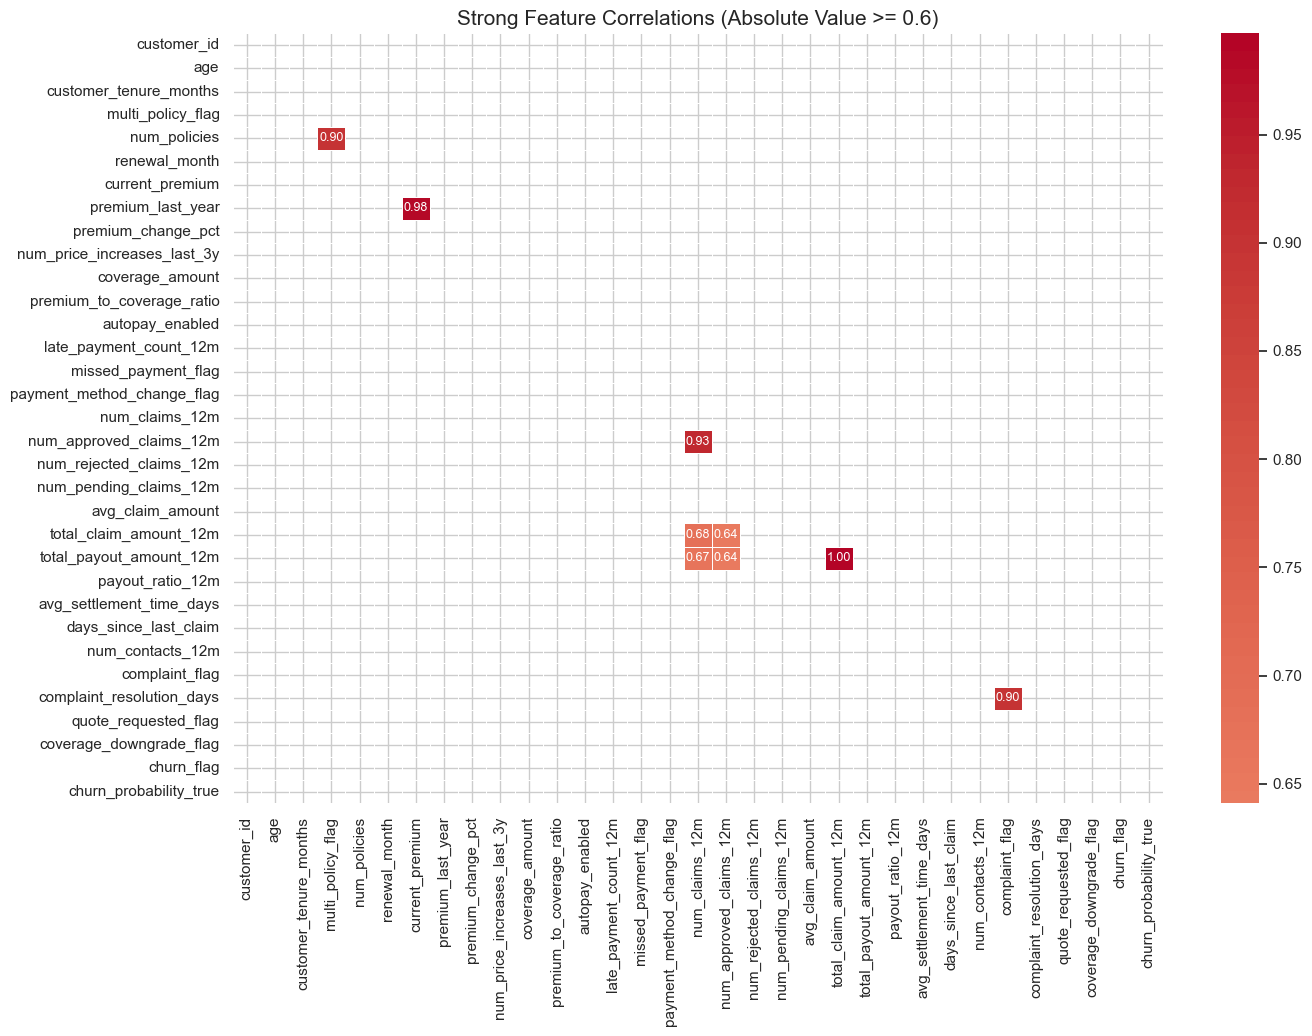


Variable A                | Variable B                | Corr  
------------------------------------------------------------
total_claim_amount_12m    | total_payout_amount_12m   |   1.00
current_premium           | premium_last_year         |   0.98
num_claims_12m            | num_approved_claims_12m   |   0.93
complaint_flag            | complaint_resolution_days |   0.90
multi_policy_flag         | num_policies              |   0.90
num_claims_12m            | total_claim_amount_12m    |   0.68
num_claims_12m            | total_payout_amount_12m   |   0.67
num_approved_claims_12m   | total_payout_amount_12m   |   0.64
num_approved_claims_12m   | total_claim_amount_12m    |   0.64


In [52]:
# 1. 상관계수 행렬 계산 (숫자형 컬럼만 대상)
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# 2. 절댓값 0.6 이상인 값만 필터링 (나머지는 NaN 처리)
filtered_corr = corr_matrix[(corr_matrix.abs() >= 0.6)]

# 3. 모든 값이 NaN인 행/열 제거 (시각화 가독성 향상)
filtered_corr = filtered_corr.dropna(how='all', axis=0).dropna(how='all', axis=1)

# --- [시각화] ---
plt.figure(figsize=(15, 10))
mask = np.triu(np.ones_like(filtered_corr, dtype=bool)) # 상단 삼각형 마스크

sns.heatmap(filtered_corr,
            mask=mask,
            annot=True,          # 숫자 표시
            fmt=".2f",           # 소수점 둘째자리
            cmap='coolwarm',     # 파란색 ~ 빨간색
            center=0,
            linewidths=.5,
            annot_kws={"size": 9})

plt.title('Strong Feature Correlations (Absolute Value >= 0.6)', fontsize=15)
plt.show()

# --- [텍스트 리스트 출력] ---
# 중복 쌍 및 자기 자신(1.0) 제거를 위한 마스킹
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
pairs = upper_triangle.unstack().dropna()

# 절댓값 0.6 이상만 필터링 및 정렬
strong_pairs = pairs[pairs.abs() >= 0.6].sort_values(ascending=False)

print("\n" + "="*60)
print(f"{'Variable A':<25} | {'Variable B':<25} | {'Corr':<6}")
print("-" * 60)

if len(strong_pairs) > 0:
    for (var2, var1), corr in strong_pairs.items():
        print(f"{var1:<25} | {var2:<25} | {corr:>6.2f}")
else:
    print("상관계수 0.6 이상인 변수 쌍이 없습니다.")

print("="*60)

In [54]:
# 1. 상관계수 행렬에서 churn_flag 열만 추출
churn_corr = corr_matrix['churn_flag'].sort_values(ascending=False)

# 2. 절댓값 0.6 이상인 변수만 필터링 (자기 자신 제외)
strong_churn_corr = churn_corr[(churn_corr.abs() >= 0.6) & (churn_corr.index != 'churn_flag')]

print("=== churn_flag와 상관계수 0.6 이상인 변수 ===")
if len(strong_churn_corr) > 0:
    print(strong_churn_corr)
else:
    print("상관계수 0.6 이상인 변수가 없습니다.")
    print("\n[참고] 상위 5개 상관관계 변수:")
    print(churn_corr[churn_corr.index != 'churn_flag'].head(5))

=== churn_flag와 상관계수 0.6 이상인 변수 ===
상관계수 0.6 이상인 변수가 없습니다.

[참고] 상위 5개 상관관계 변수:
churn_probability_true    0.505235
premium_change_pct        0.246109
late_payment_count_12m    0.206361
quote_requested_flag      0.112207
complaint_flag            0.111718
Name: churn_flag, dtype: float64


제거 대상 (Drop 후보) | 남길 대상 (Keep) | 이유
|---------------------|---------------------|-----------|
total_payout_amount_12m|total_claim_amount_12m|두 값이 1.00으로 같으므로 하나만 필요
premium_last_year|current_premium|현재 상태가 이탈에 더 중요함
num_approved_claims_12m|num_claims_12m|청구 시도 자체가 고객의 활동성을 더 잘 보여줌
complaint_resolution_days|complaint_flag|불만 발생 여부가 이탈의 직접적인 트리거임

=== [모델 지표] ===
정확도: 0.5564
F2-Score: 0.7123

[상세 리포트]
              precision    recall  f1-score   support

           0       0.90      0.41      0.56      6983
           1       0.40      0.89      0.55      3017

    accuracy                           0.56     10000
   macro avg       0.65      0.65      0.56     10000
weighted avg       0.75      0.56      0.56     10000



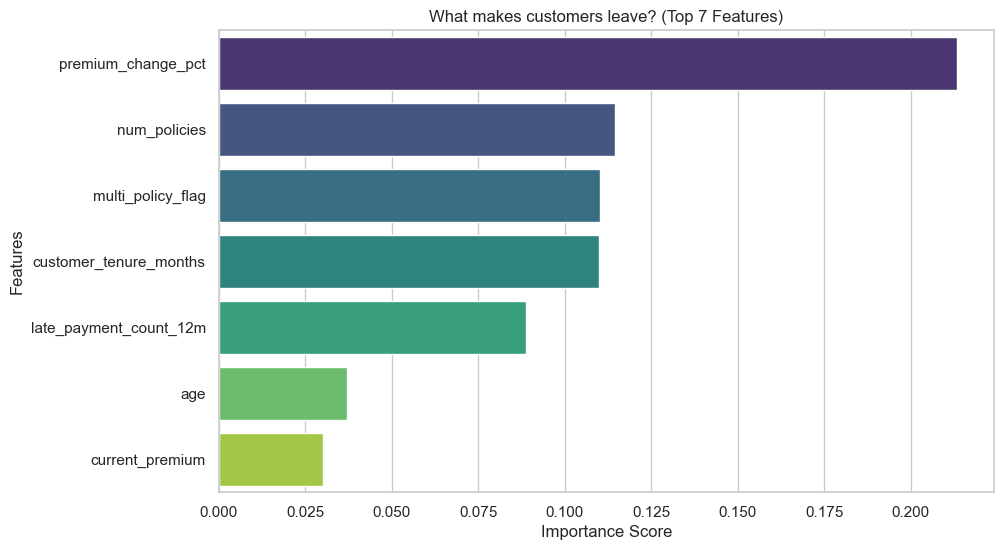

In [57]:
# 1. 데이터 준비 및 숫자형 데이터만 추출 (문자열/날짜 에러 원천 차단)
X_numeric = churn_df.select_dtypes(include=[np.number])

# 2. 반칙 변수 및 불필요한 변수 제거 (Drop List)
drop_cols = [
    'churn_flag', 'churn_type', 'churn_probability_true', # 정답 및 leakage
    'total_payout_amount_12m', # 중복
    'premium_last_year',       # 중복
    'customer_id'              # 고유 식별자
]

# 실제로 존재하는 컬럼만 골라서 제거
X = X_numeric.drop(columns=[col for col in drop_cols if col in X_numeric.columns])
y = churn_df['churn_flag']

# 3. 파생 변수 생성
X['anger_index'] = X['premium_change_pct'] * X['num_rejected_claims_12m']
X['claim_approval_rate'] = (X['num_claims_12m'] - X['num_rejected_claims_12m']) / (X['num_claims_12m'] + 0.1)
X['loyalty_pain_score'] = X['customer_tenure_months'] * X['complaint_flag']

# 4. 결측치 및 무한대 값 처리 (연산 중 오류값 제거)
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# 5. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. 최종 모델 학습
final_model = RandomForestClassifier(
    class_weight={0: 1, 1: 4},
    max_depth=12,
    min_samples_split=5,
    n_estimators=300,
    random_state=42
)
final_model.fit(X_train, y_train)

# 7. 결과 확인
y_probs = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= 0.45).astype(int)

# --- 지표 출력 ---
print(f"=== [모델 지표] ===")
print(f"정확도: {accuracy_score(y_test, y_pred):.4f}")
print(f"F2-Score: {fbeta_score(y_test, y_pred, beta=2.0):.4f}")
print("\n[상세 리포트]")
print(classification_report(y_test, y_pred))

# --- 변수 중요도 시각화 ---
plt.figure(figsize=(10, 6))
importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(7)
sns.barplot(
    x=importances,
    y=importances.index,
    hue=importances.index,  # y축 변수를 hue에 할당
    palette='viridis',
    legend=False            # 범례는숨김
)

plt.title("What makes customers leave? (Top 7 Features)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

### 파생변수 생성 설명

1anger_index (분노 지수)
- 수식: 보험료 인상률(premium_change_pct) $\times$ 거절된 청구 횟수(num_rejected_claims_12m)
- 생성 배경: 고객이 가장 크게 이탈을 고민하는 순간은 돈은 더 내는데, 혜택은 못 받을 때
- 의미: * 보험료가 조금 올랐거나 청구가 한두 번 거절된 건 참을 수 있지만 두 가지가 동시에 발생하면 고객의 불만은 커진다. 이 지점을 수치화하여 모델에 강조
2. claim_approval_rate (보험금 승인율)
- 수식: (전체 청구 - 거절된 청구) / (전체 청구 + 0.1)
- 생성 배경: 보험 서비스의 본질은 내가 필요할 때 돈을 주는가
- 의미: * 단순히 청구를 많이 했느냐보다, 그중 몇 %나 승인되었느냐가 고객 만족도에 직접적인 영향을 준다. 분모에 + 0.1을 더한 이유는 청구 건수가 0인 고객의 경우 '0으로 나누기(Division by Zero)' 에러가 발생하는 것을 방지하기 위함
3. loyalty_pain_score (장기 고객 배신감 지수)
- 수식: 가입 기간(customer_tenure_months) $\times$ 민원 발생 여부(complaint_flag)
- 생성 배경: 신규 고객보다 오래된 고객이 불만을 가질 때 이탈의 파괴력이 더 크다.
- 의미: * 가입한 지 한 달 된 고객의 불만보다, 10년 된 단골 고객이 불만을 터뜨렸을 때 훨씬 더 심각하게 이탈을 고려합니다. 가입 기간이 길수록 이 값이 커지게 설계하여, **"우리 회사를 오래 믿어준 고객이 화가 났는가?"**를 모델이 중요하게 학습하도록 함.

In [58]:
from sklearn.ensemble import HistGradientBoostingClassifier

# 1. 데이터 준비
X_numeric = churn_df.select_dtypes(include=[np.number])
drop_cols = ['churn_flag', 'churn_type', 'churn_probability_true', 'total_payout_amount_12m', 'premium_last_year']
X = X_numeric.drop(columns=[col for col in drop_cols if col in X_numeric.columns])
y = churn_df['churn_flag']

# 2. 파생 변수 생성
X['anger_index'] = X['premium_change_pct'] * X['num_rejected_claims_12m']
X['claim_approval_rate'] = (X['num_claims_12m'] - X['num_rejected_claims_12m']) / (X['num_claims_12m'] + 0.1)
X['loyalty_pain_score'] = X['customer_tenure_months'] * X['complaint_flag']

# 3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. HistGradientBoostingClassifier 모델 학습
# random_forest의 class_weight 대신 'class_weight' 파라미터를 동일하게 지원
hist_model = HistGradientBoostingClassifier(
    learning_rate=0.1,      # 학습률 (너무 낮으면 느리고, 높으면 오버슈팅)
    max_iter=200,           # 트리의 개수 (n_estimators와 유사)
    max_depth=10,           # 트리 깊이
    l2_regularization=1.5,  # 규제를 통한 과적합 방지
    class_weight={0: 1, 1: 4}, # 클래스 불균형 처리
    random_state=42
)

hist_model.fit(X_train, y_train)

# 5. 결과 확인 (임계치 0.45 적용)
y_probs_hist = hist_model.predict_proba(X_test)[:, 1]
y_pred_hist = (y_probs_hist >= 0.45).astype(int)

# --- 지표 출력 ---
print(f"=== [HistGradientBoosting] 모델 지표 ===")
print(f"정확도: {accuracy_score(y_test, y_pred_hist):.4f}")
print(f"F2-Score: {fbeta_score(y_test, y_pred_hist, beta=2.0):.4f}")
print("\n[상세 리포트]")
print(classification_report(y_test, y_pred_hist))

=== [HistGradientBoosting] 모델 지표 ===
정확도: 0.5664
F2-Score: 0.7157

[상세 리포트]
              precision    recall  f1-score   support

           0       0.90      0.43      0.58      6983
           1       0.40      0.89      0.55      3017

    accuracy                           0.57     10000
   macro avg       0.65      0.66      0.57     10000
weighted avg       0.75      0.57      0.57     10000



In [61]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, fbeta_score, classification_report

# 1. 데이터 준비 (기존 동일)
X_numeric = churn_df.select_dtypes(include=[np.number])
drop_cols = ['churn_flag', 'churn_type', 'churn_probability_true', 'total_payout_amount_12m', 'premium_last_year']
X = X_numeric.drop(columns=[col for col in drop_cols if col in X_numeric.columns])
y = churn_df['churn_flag']

# 2. 파생 변수 생성
X['anger_index'] = X['premium_change_pct'] * X['num_rejected_claims_12m']
X['claim_approval_rate'] = (X['num_claims_12m'] - X['num_rejected_claims_12m']) / (X['num_claims_12m'] + 0.1)
X['loyalty_pain_score'] = X['customer_tenure_months'] * X['complaint_flag']

# 3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. XGBoost 모델 설정 (에러 원인인 use_label_encoder 제거)
ratio = (y == 0).sum() / (y == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=ratio * 1.5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',      # 최신 버전에서는 이 설정으로 충분합니다.
    random_state=42
)

# 5. 모델 학습 (Scikit-learn 인터페이스를 사용하므로 bst.update 대신 .fit() 사용)
xgb_model.fit(X_train, y_train)

# 6. 결과 확인
y_probs = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= 0.45).astype(int)

print(f"=== [XGBoost] 모델 지표 ===")
print(f"정확도: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"F2-Score: {fbeta_score(y_test, y_pred_xgb, beta=2.0):.4f}")
print("\n[상세 리포트]")
print(classification_report(y_test, y_pred_xgb))

=== [XGBoost] 모델 지표 ===
정확도: 0.6219
F2-Score: 0.6980

[상세 리포트]
              precision    recall  f1-score   support

           0       0.88      0.53      0.66      6983
           1       0.43      0.82      0.57      3017

    accuracy                           0.62     10000
   macro avg       0.65      0.68      0.62     10000
weighted avg       0.74      0.62      0.63     10000

